In [ ]:
import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore
import warnings
import spacy # type: ignore
from collections import Counter

warnings.filterwarnings('ignore')

In [2]:
nlp = spacy.load('en_core_web_sm')

In [3]:
df = pd.read_csv(r'D:\End-to-end-ML\Customer-Risk-Escalation-Engine\data\raw_data\support_tkts.csv')
df

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3,Corporate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,199996,Barbara Martinez,barbara.martinez691@hotmail.com,Billing System,Bug Report,There seems to be a discrepancy in my billing ...,Payment gateway timeout issue fixed and monito...,Urgent,Closed,Social Media,...,2024-01-16,No,No,Linux,Safari,Credit Card,French,Morning,7,Small Business
199996,199997,James Hernandez,james.hernandez188@hotmail.com,E-commerce Store,Login Issue,Two-factor authentication codes are not being ...,Provided step-by-step troubleshooting instruct...,Low,Open,Web Form,...,2022-05-18,No,Yes,MacOS,Safari,Bank Transfer,English,Evening,3,Individual
199997,199998,Michael Thomas,michael.thomas66@company.com,Web Portal,Refund Request,Two-factor authentication codes are not being ...,Provided step-by-step troubleshooting instruct...,Low,Closed,Chat,...,2022-04-30,Yes,No,Windows,Chrome,Bank Transfer,French,Morning,5,Small Business
199998,199999,Barbara Taylor,barbara.taylor486@outlook.com,Billing System,Performance Issue,There seems to be a discrepancy in my billing ...,Explained billing breakdown and clarified appl...,Urgent,Pending Customer,Social Media,...,2024-01-27,No,Yes,iOS,Chrome,PayPal,Spanish,Night,6,Small Business


In [4]:
df.shape

(200000, 30)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ticket_id                    200000 non-null  int64  
 1   customer_name                200000 non-null  object 
 2   customer_email               200000 non-null  object 
 3   product                      200000 non-null  object 
 4   category                     200000 non-null  object 
 5   issue_description            200000 non-null  object 
 6   resolution_notes             200000 non-null  object 
 7   priority                     200000 non-null  object 
 8   status                       200000 non-null  object 
 9   channel                      200000 non-null  object 
 10  region                       200000 non-null  object 
 11  customer_age                 200000 non-null  int64  
 12  customer_gender              200000 non-null  object 
 13 

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ticket_id,200000.0,100000.500000,57735.171256,1.0,50000.75,100000.50,150000.25,200000.0
customer_age,200000.0,46.469040,16.754304,18.0,32.00,46.00,61.00,75.0
customer_tenure_months,200000.0,30.377675,17.326224,1.0,15.00,30.00,45.00,60.0
previous_tickets,200000.0,9.992115,6.053142,0.0,5.00,10.00,15.00,20.0
customer_satisfaction_score,200000.0,3.001065,1.412273,1.0,2.00,3.00,4.00,5.0
first_response_time_hours,200000.0,36.309180,20.654575,0.5,18.46,36.31,54.22,72.0
resolution_time_hours,200000.0,120.539718,68.969143,1.0,60.81,120.45,180.26,240.0
issue_complexity_score,200000.0,5.501365,2.875587,1.0,3.00,6.00,8.00,10.0


In [7]:
df.isnull().sum()

ticket_id                          0
customer_name                      0
customer_email                     0
product                            0
category                           0
issue_description                  0
resolution_notes                   0
priority                           0
status                             0
channel                            0
region                             0
customer_age                       0
customer_gender                    0
subscription_type                  0
customer_tenure_months             0
previous_tickets                   0
customer_satisfaction_score        0
first_response_time_hours          0
resolution_time_hours              0
ticket_created_date                0
ticket_resolved_date               0
escalated                          0
sla_breached                       0
operating_system                   0
browser                        40023
payment_method                     0
language                           0
p

In [8]:
df.isnull().sum() / len(df)*100

ticket_id                       0.0000
customer_name                   0.0000
customer_email                  0.0000
product                         0.0000
category                        0.0000
issue_description               0.0000
resolution_notes                0.0000
priority                        0.0000
status                          0.0000
channel                         0.0000
region                          0.0000
customer_age                    0.0000
customer_gender                 0.0000
subscription_type               0.0000
customer_tenure_months          0.0000
previous_tickets                0.0000
customer_satisfaction_score     0.0000
first_response_time_hours       0.0000
resolution_time_hours           0.0000
ticket_created_date             0.0000
ticket_resolved_date            0.0000
escalated                       0.0000
sla_breached                    0.0000
operating_system                0.0000
browser                        20.0115
payment_method           

In [9]:
df['priority'].value_counts()

priority
High      50241
Urgent    50143
Medium    49854
Low       49762
Name: count, dtype: int64

In [10]:
df['priority'].value_counts(normalize=True)*100


priority
High      25.1205
Urgent    25.0715
Medium    24.9270
Low       24.8810
Name: proportion, dtype: float64

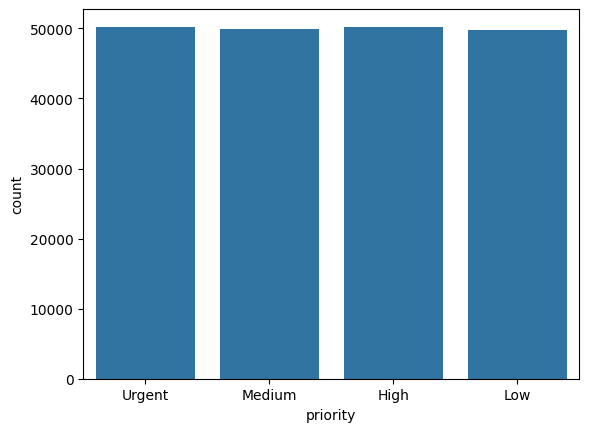

In [11]:
sns.countplot(x='priority',data=df)
plt.show();

In [12]:
df['escalated'].value_counts()

escalated
Yes    100421
No      99579
Name: count, dtype: int64

In [13]:
df['escalated'].value_counts(normalize=True)*100

escalated
Yes    50.2105
No     49.7895
Name: proportion, dtype: float64

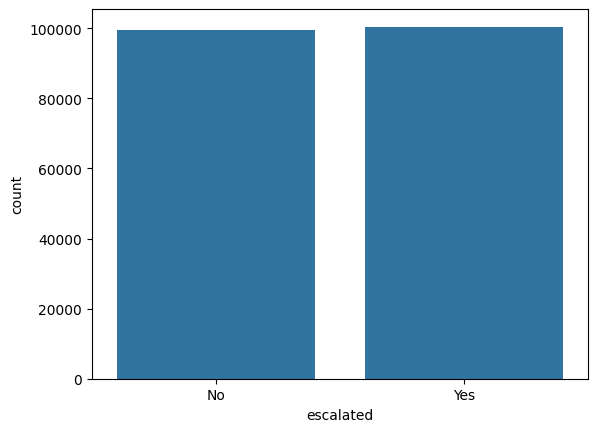

In [14]:
sns.countplot(x='escalated',data=df)
plt.show();

In [15]:
pd.crosstab(df['priority'],df['escalated'],normalize='index')*100

escalated,No,Yes
priority,,
High,49.801955,50.198045
Low,50.092440,49.907560
Medium,49.506559,50.493441
Urgent,49.757693,50.242307


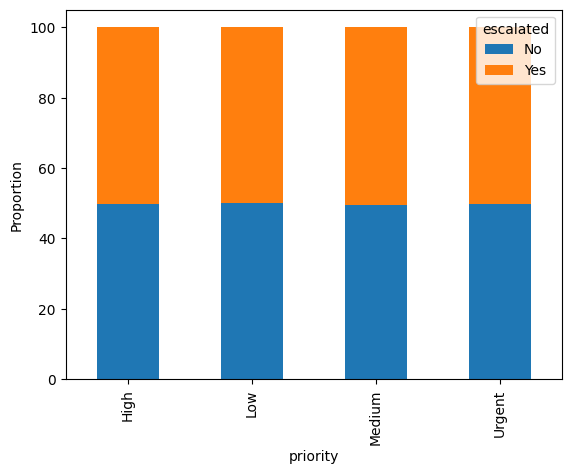

In [16]:
ct = pd.crosstab(df['priority'],df['escalated'],normalize='index')*100
ct.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.show();

In [17]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical Columns ({len(num_cols)}):")
print(num_cols)

Numerical Columns (8):
['ticket_id', 'customer_age', 'customer_tenure_months', 'previous_tickets', 'customer_satisfaction_score', 'first_response_time_hours', 'resolution_time_hours', 'issue_complexity_score']


In [18]:
cat_cols = df.select_dtypes(include=['O']).columns.tolist()
print(f"Categorical Columns ({len(cat_cols)}):")
print(cat_cols)


Categorical Columns (22):
['customer_name', 'customer_email', 'product', 'category', 'issue_description', 'resolution_notes', 'priority', 'status', 'channel', 'region', 'customer_gender', 'subscription_type', 'ticket_created_date', 'ticket_resolved_date', 'escalated', 'sla_breached', 'operating_system', 'browser', 'payment_method', 'language', 'preferred_contact_time', 'customer_segment']


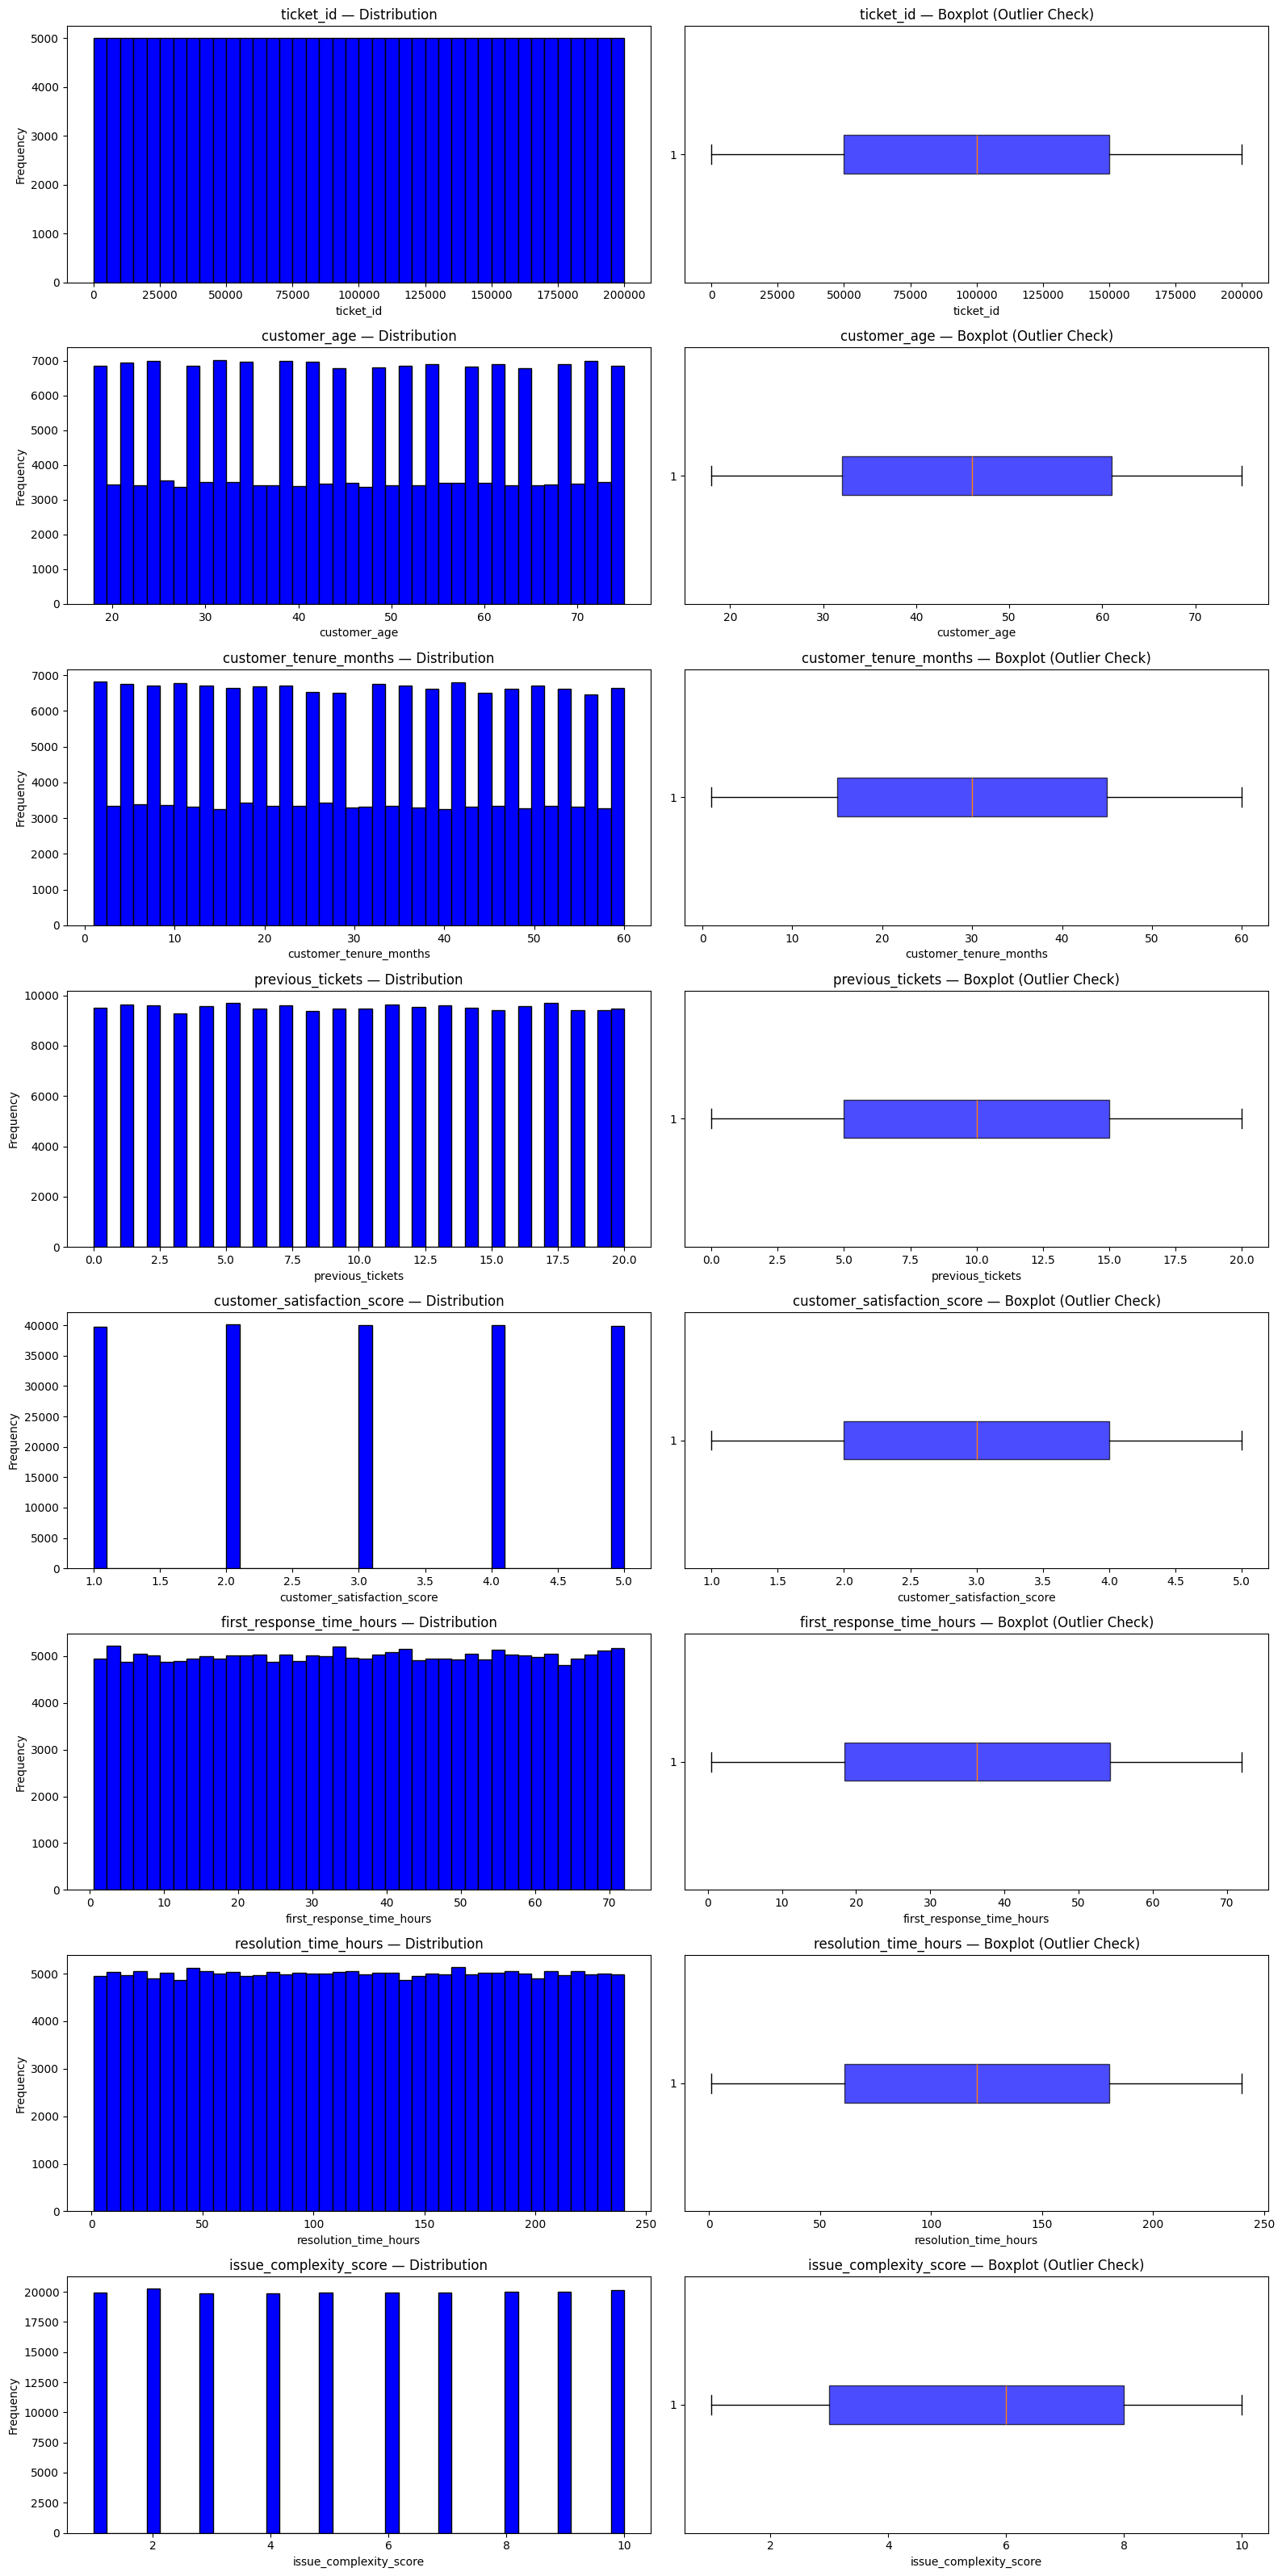

In [19]:
# Distribution plots for all numerical columns
n = len(num_cols)
fig, axes = plt.subplots(n, 2, figsize=(16, n * 4))

for i, col in enumerate(num_cols):
    # Histogram
    axes[i, 0].hist(
        df[col].dropna(),
        bins=40,
        color='blue',
        edgecolor='black'
    )
    axes[i, 0].set_title(f'{col} — Distribution', fontsize=12)
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    # Boxplot (detects outliers)
    axes[i, 1].boxplot(
        df[col].dropna(),
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor='blue', alpha=0.7)
    )
    axes[i, 1].set_title(f'{col} — Boxplot (Outlier Check)', fontsize=12)
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

In [20]:
df[num_cols].skew()

ticket_id                      0.000000
customer_age                   0.005349
customer_tenure_months         0.006800
previous_tickets               0.000053
customer_satisfaction_score   -0.000297
first_response_time_hours     -0.002889
resolution_time_hours         -0.000219
issue_complexity_score         0.000066
dtype: float64

In [21]:
print("UNIQUE VALUE COUNTS PER CATEGORICAL COLUMN")
print("=" * 50)
for col in cat_cols:
    print(f"{col:40} → {df[col].nunique()} unique values")

UNIQUE VALUE COUNTS PER CATEGORICAL COLUMN
customer_name                            → 400 unique values
customer_email                           → 191751 unique values
product                                  → 10 unique values
category                                 → 10 unique values
issue_description                        → 10 unique values
resolution_notes                         → 10 unique values
priority                                 → 4 unique values
status                                   → 5 unique values
channel                                  → 5 unique values
region                                   → 6 unique values
customer_gender                          → 3 unique values
subscription_type                        → 4 unique values
ticket_created_date                      → 1096 unique values
ticket_resolved_date                     → 1110 unique values
escalated                                → 2 unique values
sla_breached                             → 2 unique val

In [22]:
print("VALUE COUNTS FOR CATEGORICAL COLUMNS WITH < 200 UNIQUE VALUES")
print("=" * 60)

for col in cat_cols:
    if df[col].nunique() < 200:
        print(f"\nColumn: {col}")
        print("-" * 40)
        print(df[col].value_counts())

VALUE COUNTS FOR CATEGORICAL COLUMNS WITH < 200 UNIQUE VALUES

Column: product
----------------------------------------
product
Billing System          20111
CRM Platform            20097
E-commerce Store        20095
Cloud Storage           20056
Mobile App              20043
Analytics Dashboard     19974
Web Portal              19954
Payment Gateway         19952
Subscription Service    19883
API Service             19835
Name: count, dtype: int64

Column: category
----------------------------------------
category
Feature Request              20169
Subscription Cancellation    20096
Performance Issue            20074
Security Concern             20040
Login Issue                  20002
Payment Problem              19997
Bug Report                   19981
Refund Request               19900
Data Sync Issue              19877
Account Suspension           19864
Name: count, dtype: int64

Column: issue_description
----------------------------------------
issue_description
There seems to b

In [23]:
df['char_count'] = df['issue_description'].fillna("").apply(len)

In [24]:
df['char_count'].describe()

count    200000.000000
mean         65.923705
std           8.056100
min          55.000000
25%          56.000000
50%          68.000000
75%          72.000000
max          79.000000
Name: char_count, dtype: float64

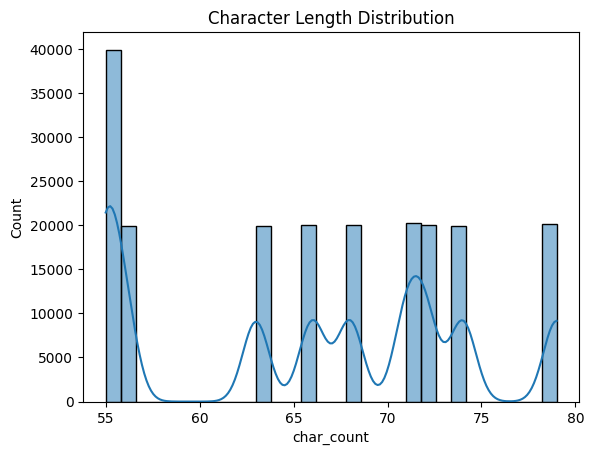

In [25]:
#This graph shows Number of characters in a ticket description to Number of tickets having that character count.
#E.g -> char_count = 55, count = 40,000 -> it means: Around 40,000 ticket descriptions contain approximately 55 characters.

sns.histplot(df['char_count'], bins=30, kde=True) # type: ignore
plt.title("Character Length Distribution")
plt.show()

In [26]:
def word_count(text):
    doc = nlp(str(text))
    
    return len([
        token
        for token in doc
        if not token.is_punct
        and not token.is_space
    ])

In [27]:
df['word_count'] = df['issue_description'].apply(word_count)

In [28]:
df['word_count'].describe()

count    200000.000000
mean         11.105155
std           1.222508
min           9.000000
25%          10.000000
50%          11.000000
75%          12.000000
max          13.000000
Name: word_count, dtype: float64

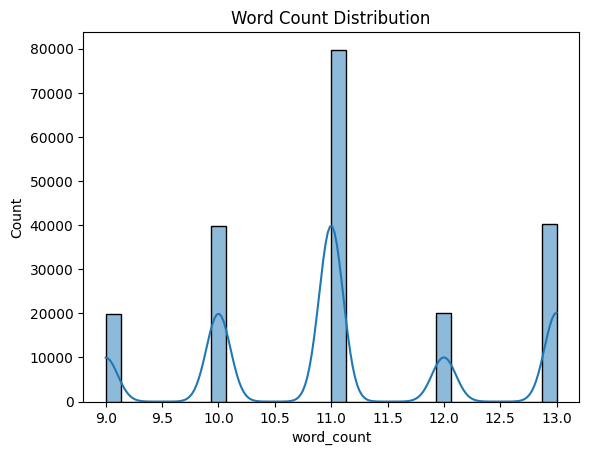

In [29]:
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title("Word Count Distribution")
plt.show()

In [30]:
df.groupby('priority')['word_count'].mean()

priority
High      11.099998
Low       11.111310
Medium    11.105929
Urgent    11.103444
Name: word_count, dtype: float64

In [32]:
df.groupby('escalated')['word_count'].mean()

escalated
No     11.103666
Yes    11.106631
Name: word_count, dtype: float64

In [34]:
all_words = []
for text in df['issue_description'].fillna(""):
    doc = nlp(text)
    for token in doc:
        if (
            not token.is_stop
            and not token.is_punct
            and not token.is_space
            and token.is_alpha
        ):
            all_words.append(token.lemma_.lower())

In [35]:
word_freq = Counter(all_words)

print(word_freq.most_common(20))

[('account', 40183), ('request', 39890), ('discrepancy', 20232), ('billing', 20232), ('statement', 20232), ('month', 20232), ('payment', 20126), ('deduct', 20126), ('bank', 20126), ('transaction', 20126), ('show', 20126), ('fail', 20126), ('unable', 20057), ('access', 20057), ('enter', 20057), ('correct', 20057), ('credential', 20057), ('factor', 19988), ('authentication', 19988), ('code', 19988)]


In [36]:
df['issue_description'].duplicated().sum()


199990

In [37]:
df.duplicated().sum()

0

In [38]:
corr = df[num_cols].corr()

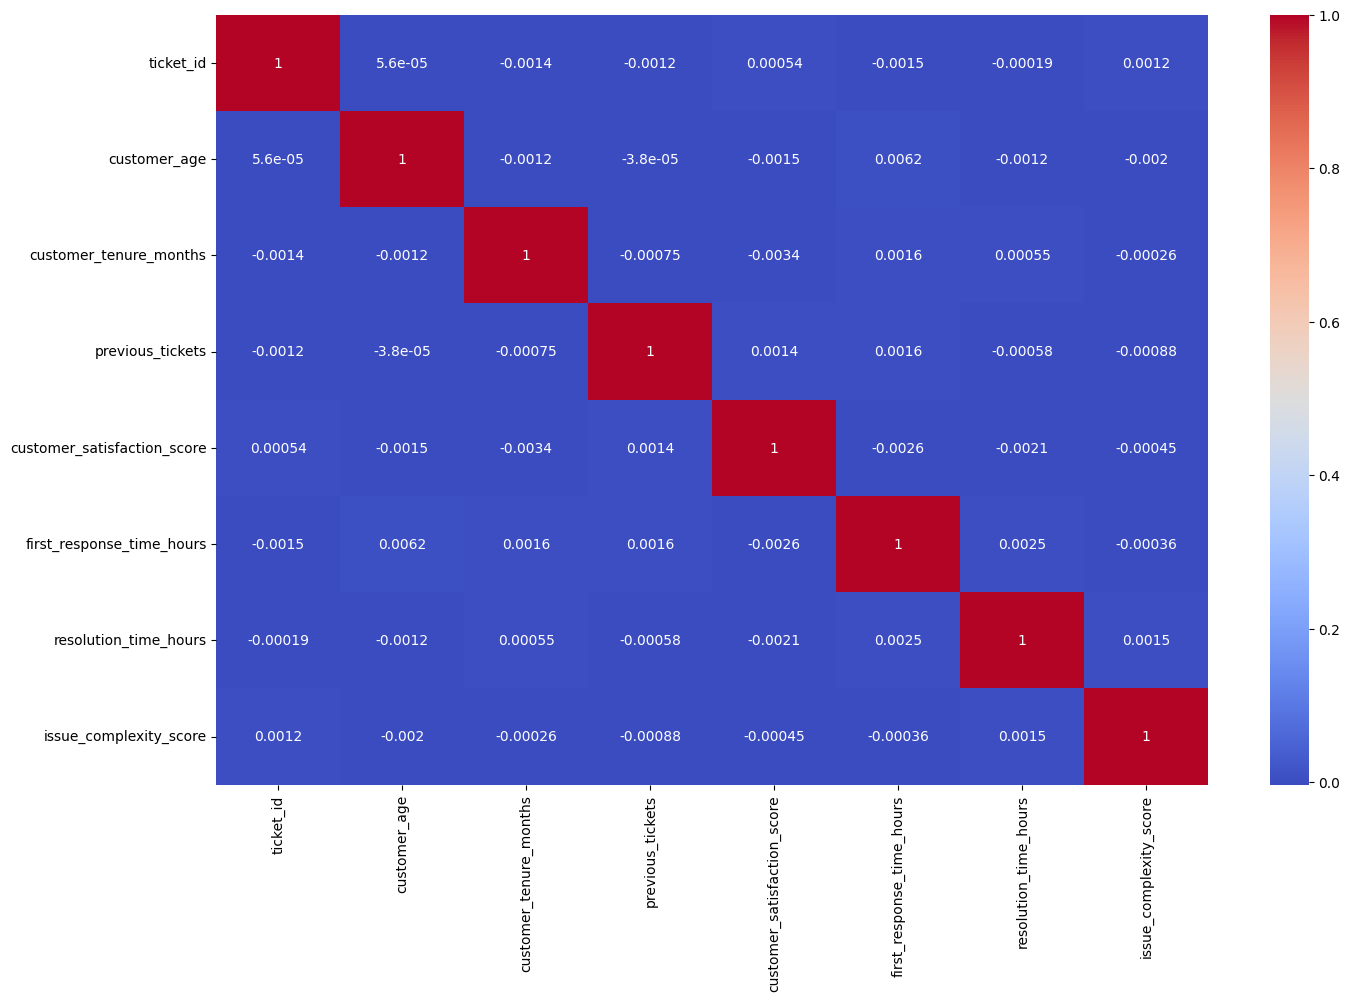

In [43]:
plt.figure(figsize=(16,10))
sns.heatmap(corr,cmap='coolwarm',annot=True)
plt.show();

In [44]:
df['escalated'] = df['escalated'].map({"Yes":1,"No":0})

In [46]:
df['escalated']

0         0
1         1
2         1
3         1
4         1
         ..
199995    0
199996    0
199997    1
199998    0
199999    0
Name: escalated, Length: 200000, dtype: int64

In [48]:
corr_with_target = (df[num_cols+['escalated']].corr()['escalated'])
print(corr_with_target)

ticket_id                      0.002769
customer_age                  -0.002629
customer_tenure_months        -0.000530
previous_tickets               0.001762
customer_satisfaction_score   -0.001423
first_response_time_hours     -0.000970
resolution_time_hours         -0.000831
issue_complexity_score        -0.000096
escalated                      1.000000
Name: escalated, dtype: float64


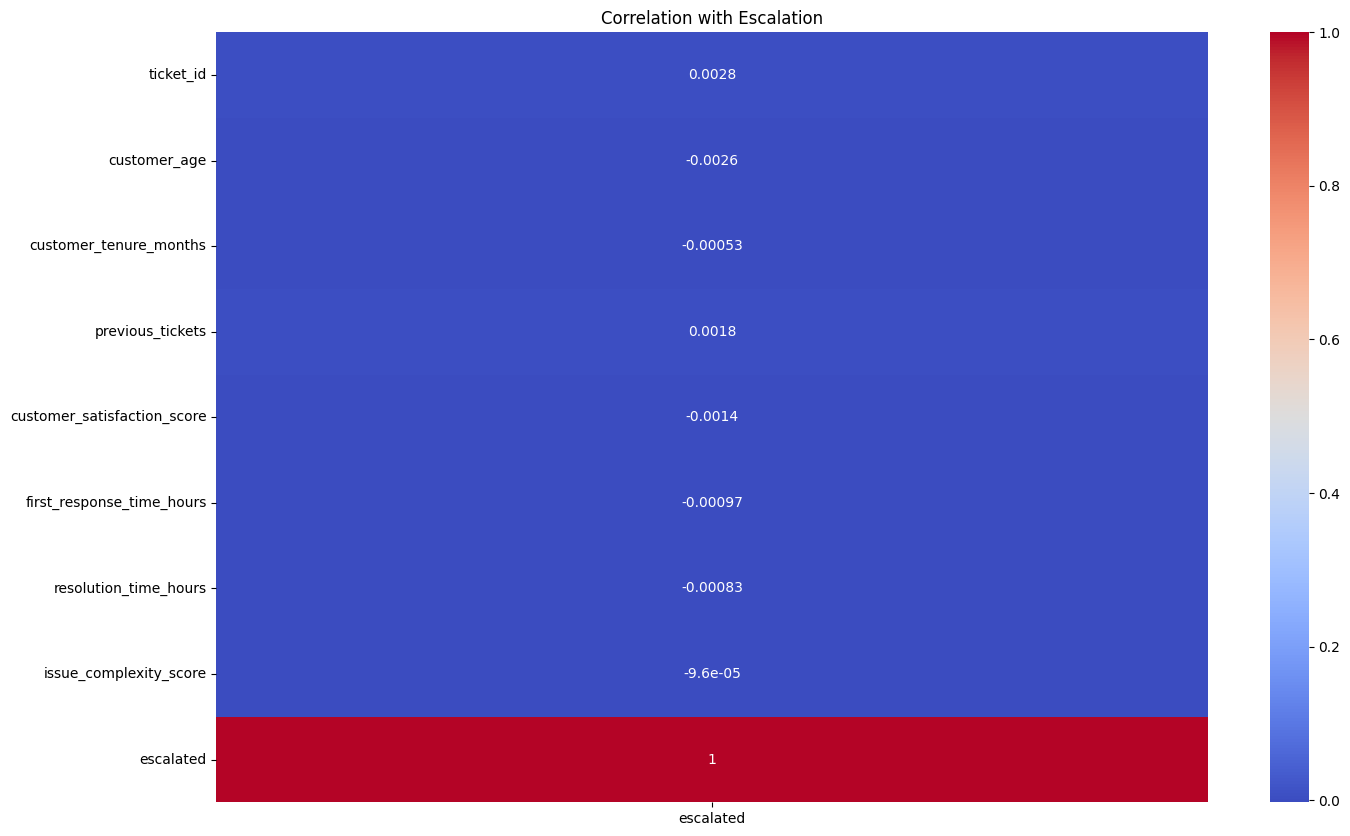

In [49]:
plt.figure(figsize=(16,10))

sns.heatmap(
    corr_with_target.to_frame(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation with Escalation')
plt.show()

In [50]:
df['ticket_created_date'] = pd.to_datetime(df['ticket_created_date'])
df['ticket_resolved_date'] = pd.to_datetime(df['ticket_resolved_date'])

In [51]:
print(df[['ticket_created_date', 'ticket_resolved_date']].dtypes)

ticket_created_date     datetime64[ns]
ticket_resolved_date    datetime64[ns]
dtype: object


In [53]:
print("Start Date:", df['ticket_created_date'].min())
print("End Date:", df['ticket_created_date'].max())

duration = (
    df['ticket_created_date'].max()
    - df['ticket_created_date'].min()
)

print("Duration:", duration)

Start Date: 2022-01-01 00:00:00
End Date: 2024-12-31 00:00:00
Duration: 1095 days 00:00:00


In [54]:
df['year_month'] = (
    df['ticket_created_date']
    .dt.to_period('M')
)

In [55]:
monthly_volume = (
    df.groupby('year_month')
      .size()
)

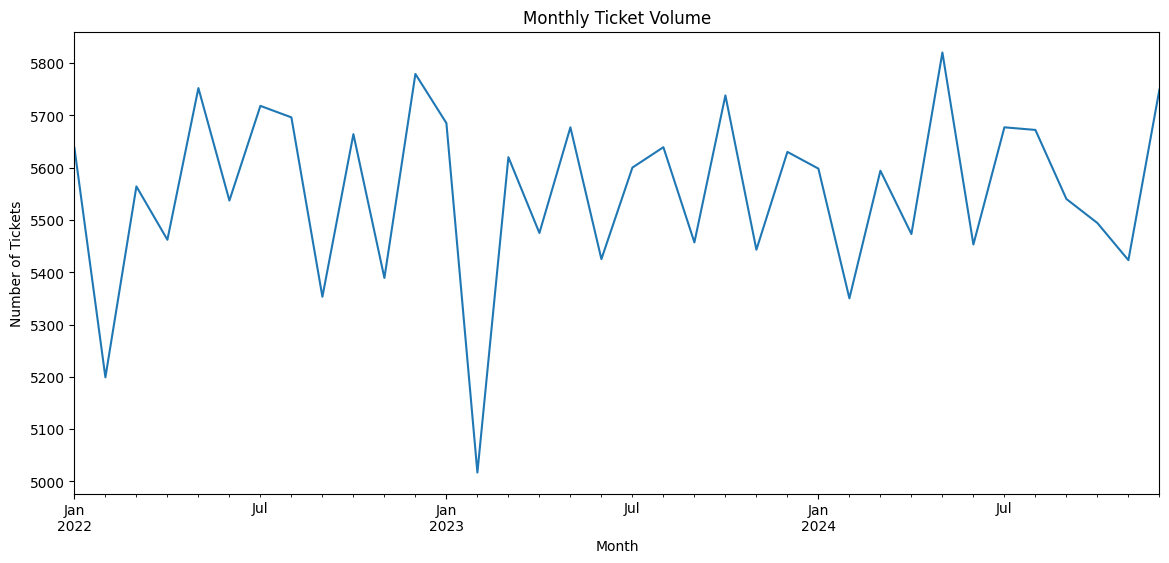

In [56]:
plt.figure(figsize=(14,6))

monthly_volume.plot()

plt.title("Monthly Ticket Volume")
plt.xlabel("Month")
plt.ylabel("Number of Tickets")

plt.show()

In [58]:
monthly_escalation = (
    df.groupby('year_month')['escalated']
      .mean()
      * 100
)
print(monthly_escalation)

year_month
2022-01    49.787159
2022-02    49.624928
2022-03    50.305536
2022-04    50.128158
2022-05    49.652295
2022-06    50.316056
2022-07    50.069955
2022-08    50.456461
2022-09    50.140108
2022-10    50.723870
2022-11    50.120616
2022-12    51.271846
2023-01    48.953386
2023-02    51.166035
2023-03    50.871886
2023-04    50.155251
2023-05    48.617227
2023-06    50.322581
2023-07    50.589286
2023-08    50.186203
2023-09    51.493495
2023-10    49.058906
2023-11    50.321514
2023-12    49.626998
2024-01    50.160772
2024-02    49.925234
2024-03    50.321773
2024-04    49.260004
2024-05    51.529210
2024-06    50.027508
2024-07    50.325876
2024-08    49.735543
2024-09    49.855596
2024-10    50.345832
2024-11    49.769500
2024-12    52.339537
Freq: M, Name: escalated, dtype: float64


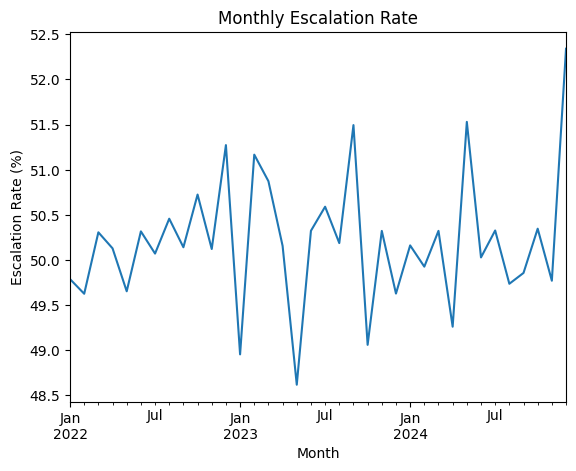

In [59]:
monthly_escalation.plot()

plt.title("Monthly Escalation Rate")
plt.ylabel("Escalation Rate (%)")
plt.xlabel("Month")

plt.show()

In [60]:
df['day_of_week'] = (
    df['ticket_created_date']
    .dt.day_name()
)

In [61]:
day_volume = (
    df['day_of_week']
    .value_counts()
)

In [62]:
days = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_volume = (
    df['day_of_week']
    .value_counts()
    .reindex(days)
)

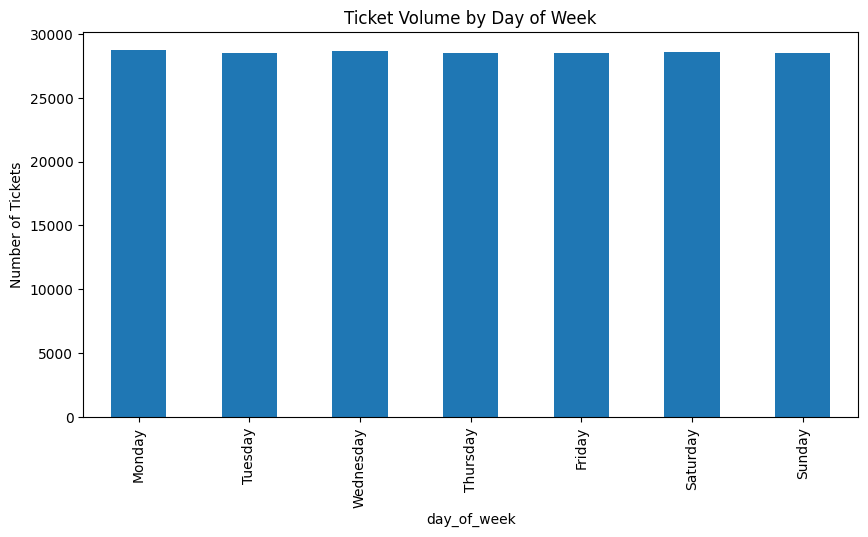

In [63]:
plt.figure(figsize=(10,5))

day_volume.plot(kind='bar')

plt.title("Ticket Volume by Day of Week")
plt.ylabel("Number of Tickets")

plt.show()

In [66]:
customer_mail_counts = (
    df.groupby('customer_name')['customer_email']
      .count()
)

customer_mail_counts.describe()

count    400.000000
mean     500.000000
std       22.708461
min      426.000000
25%      485.000000
50%      500.500000
75%      516.000000
max      568.000000
Name: customer_email, dtype: float64

In [67]:
repeat_emails = customer_mail_counts[
    customer_mail_counts > 1
]

print("Repeat Emails:", len(repeat_emails))

Repeat Emails: 400


In [68]:
customer_ticket_counts = (
    df.groupby('customer_email')['ticket_id']
      .count()
)

print(customer_ticket_counts.describe())

count    191751.000000
mean          1.043019
std           0.208879
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: ticket_id, dtype: float64


In [69]:
repeat_customers = customer_ticket_counts[
    customer_ticket_counts > 1
]

print("Repeat Customers:", len(repeat_customers))

Repeat Customers: 8019


In [72]:
escalation_by_previous = (
    df.groupby('previous_tickets')
      ['escalated']
      .mean()
      * 100
)
print(escalation_by_previous)

previous_tickets
0     49.837202
1     50.472924
2     50.359338
3     50.710288
4     50.591190
5     49.340614
6     49.926098
7     49.781068
8     50.383550
9     50.084299
10    49.878602
11    50.000000
12    51.006500
13    50.411501
14    49.227211
15    50.260500
16    50.281661
17    49.974235
18    49.957519
19    50.558332
20    51.412013
Name: escalated, dtype: float64
